<a href="https://colab.research.google.com/github/ykim68ncstate/ECE592_GenAI-Introandapplication_Project_ykim68/blob/main/Final/ykim68_Project_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Final**: Physics-Grounded Generative HVAC Diagnosis
* **Name/Unity ID:** Yujin Kim / ykim68
* **Course: ECE 592** Gen AI: Intro and Applications
* **Assignements:** Project Milestone


This project develops a physics-grounded generative diagnostic system for analyzing Air Handling Unit (AHU) operations using Building Automation System (BAS) data. A data-driven pipeline is constructed to process time-series sensor data, compute thermodynamically consistent cooling loads, and estimate fan energy consumption.

This notebook performs three tasks using AHU operational data:

1. Calculates physically meaningful values: cooling load, fan power, outdoor air fraction, etc.

2. Evaluates operational efficiency based on rule-based criteria: whether outdoor air is overused or underused, and whether the Supply Air Temperature (SAT) is too low under low-load conditions.

3. Assesses whether an LLM can explain the results in natural language: baseline, improved prompt, and comparison.

In [ ]:
## import library
import pandas as pd
import numpy as np
from functools import reduce
import matplotlib.pyplot as plt
import os
from openai import OpenAI
from getpass import getpass
import json
import re

In [ ]:
# load HVAC data files
from google.colab import files
uploaded = files.upload()

Saving AHU-2 AvgMaTmp.xlsx to AHU-2 AvgMaTmp.xlsx
Saving AHU-2 OaFl.xlsx to AHU-2 OaFl.xlsx
Saving AHU-2 OaTmp.xlsx to AHU-2 OaTmp.xlsx
Saving AHU-2 RaTmp1.xlsx to AHU-2 RaTmp1.xlsx
Saving AHU-2 RaTmp2.xlsx to AHU-2 RaTmp2.xlsx
Saving AHU-2 RaTmp3.xlsx to AHU-2 RaTmp3.xlsx
Saving AHU-2 SaFanASpd.xlsx to AHU-2 SaFanASpd.xlsx
Saving AHU-2 SaFanBSpd.xlsx to AHU-2 SaFanBSpd.xlsx
Saving AHU-2 SaFanCSpd.xlsx to AHU-2 SaFanCSpd.xlsx
Saving AHU-2 SaFanDSpd.xlsx to AHU-2 SaFanDSpd.xlsx
Saving AHU-2 SaFanESpd.xlsx to AHU-2 SaFanESpd.xlsx
Saving AHU-2 SaFanFSpd.xlsx to AHU-2 SaFanFSpd.xlsx
Saving AHU-2 SaFl.xlsx to AHU-2 SaFl.xlsx
Saving AHU-2 SaStPr.xlsx to AHU-2 SaStPr.xlsx
Saving AHU-2 SaTmp.xlsx to AHU-2 SaTmp.xlsx


# **Layer 1.** Data & Physics Engine

BAS data from an AHU is processed to compute key operational indicators:
* Mixed Air Temperature (MA)
* Supply Air Temperature (SA)
* Airflow (CFM)
* Cooling Load (BTu/h, kW thermal)
* Cooling Energy (kWh thermal)
* Fan Power(kW, estimated)
* Fan Energy (kWh)

## (1) Data Pre-processing
Historical data logs from the Building Automation System (BAS) are generated as separate files for each sensor. Therefore, each Excel file needs to be read and stored as a DataFrame, and then merged based on timestamps.

In addition, although there are multiple Supply and Return fans in reality, their values should be aggregated into a single value (e.g., summed or averaged) when evaluating HVAC operation.

In [ ]:
dfs = {}

for filename in uploaded.keys():
    if filename.endswith(".xlsx"):
       df = pd.read_excel(filename)
    elif filename.endswith(".csv"):
       try:
         df = pd.read_csv(filename, encoding="utf-8")
       except:
         df = pd.read_csv(filename, encoding="latin1")
    else:
        print(f"Skipping unsupported file: {filename}")
        continue

    dfs[filename] = df
    print(f"{filename} loaded: {df.shape}")


AHU-2 AvgMaTmp.xlsx loaded: (34366, 2)
AHU-2 OaFl.xlsx loaded: (34387, 2)
AHU-2 OaTmp.xlsx loaded: (34393, 2)
AHU-2 RaTmp1.xlsx loaded: (34393, 2)
AHU-2 RaTmp2.xlsx loaded: (34391, 2)
AHU-2 RaTmp3.xlsx loaded: (34393, 2)
AHU-2 SaFanASpd.xlsx loaded: (34387, 2)
AHU-2 SaFanBSpd.xlsx loaded: (34394, 2)
AHU-2 SaFanCSpd.xlsx loaded: (34390, 2)
AHU-2 SaFanDSpd.xlsx loaded: (34391, 2)
AHU-2 SaFanESpd.xlsx loaded: (34395, 2)
AHU-2 SaFanFSpd.xlsx loaded: (34392, 2)
AHU-2 SaFl.xlsx loaded: (34385, 2)
AHU-2 SaStPr.xlsx loaded: (34392, 2)
AHU-2 SaTmp.xlsx loaded: (34391, 2)


In [ ]:
for name, df in dfs.items():
    print("===", name, "===")
    print(df.head())
    print(df.columns.tolist())
    print()

=== AHU-2 AvgMaTmp.xlsx ===
              Time stamp  AHU-2 AvgMaTmp
0  10/25/2025 6:50:49 PM       66.730759
1  10/25/2025 6:35:49 PM       66.869202
2  10/25/2025 6:20:49 PM       67.076904
3  10/25/2025 6:05:49 PM       67.215378
4  10/25/2025 5:50:49 PM       67.423096
['Time stamp', 'AHU-2 AvgMaTmp']

=== AHU-2 OaFl.xlsx ===
               Time stamp  AHU-2 OaFl
0   10/26/2025 1:50:49 AM     11557.0
1   10/26/2025 1:35:49 AM      8833.5
2   10/26/2025 1:20:49 AM     10231.0
3   10/26/2025 1:05:49 AM      5369.0
4  10/26/2025 12:50:49 AM      7514.0
['Time stamp', 'AHU-2 OaFl']

=== AHU-2 OaTmp.xlsx ===
               Time stamp  AHU-2 OaTmp
0   10/26/2025 1:50:49 AM    45.009998
1   10/26/2025 1:35:49 AM    45.139999
2   10/26/2025 1:20:49 AM    45.180000
3   10/26/2025 1:05:49 AM    45.720001
4  10/26/2025 12:50:49 AM    46.259998
['Time stamp', 'AHU-2 OaTmp']

=== AHU-2 RaTmp1.xlsx ===
               Time stamp  AHU-2 RaTmp1
0   10/26/2025 1:50:49 AM     72.615387
1   10/26/2025

In [ ]:
cleaned_dfs = []

for filename, df in dfs.items():
    cols = df.columns.tolist()

    time_col = cols[0]
    value_col = cols[1]

    df[time_col] = pd.to_datetime(df[time_col])

    df = df.sort_values(time_col)

    sensor_name = filename.split(".")[0]

    df = df[[time_col, value_col]].rename(columns={
        time_col: "timestamp",
        value_col: sensor_name
    })

    cleaned_dfs.append(df)

/tmp/ipykernel_5840/362647346.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[time_col] = pd.to_datetime(df[time_col])
/tmp/ipykernel_5840/362647346.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[time_col] = pd.to_datetime(df[time_col])


In [ ]:
merged_df = reduce(lambda left, right:pd.merge(left, right, on="timestamp", how="inner"), cleaned_dfs) #merge data
merged_df.head()

,timestamp,AHU-2 AvgMaTmp,AHU-2 OaFl,AHU-2 OaTmp,AHU-2 RaTmp1,AHU-2 RaTmp2,AHU-2 RaTmp3,AHU-2 SaFanASpd,AHU-2 SaFanBSpd,AHU-2 SaFanCSpd,AHU-2 SaFanDSpd,AHU-2 SaFanESpd,AHU-2 SaFanFSpd,AHU-2 SaFl,AHU-2 SaStPr,AHU-2 SaTmp
0,2024-11-01 23:01:13,69.915405,5297.50,65.860001,75.015381,69.107719,70.353859,50.996346,50.996346,50.996346,50.996346,50.996346,50.996346,14409.623047,1.264688,54.892303
1,2024-11-01 23:16:13,69.869209,5440.50,65.879997,74.923088,69.107719,70.353859,49.974602,49.974602,49.974602,49.974602,49.974602,49.974602,13864.597656,1.229687,55.076923
2,2024-11-01 23:31:13,69.823059,3796.00,65.860001,75.107712,69.061523,70.307693,47.374275,47.374275,47.374275,47.374275,47.374275,47.374275,13197.990234,1.110937,55.030796
3,2024-11-01 23:46:13,69.799988,5466.50,65.769997,74.876961,69.107719,70.261566,52.612144,52.612144,52.612144,52.612144,52.612144,52.612144,15122.347656,1.299688,54.984631
4,2024-11-02 00:01:13,69.799988,5229.25,65.980003,75.153870,69.061523,70.261566,48.546005,48.546005,48.546005,48.546005,48.546005,48.546005,13537.583008,1.173750,55.076923


In [ ]:
# Assign column names
merged_df = merged_df.rename(columns={
    "AHU-2 AvgMaTmp": "MA_T",
    "AHU-2 OaFl": "OA_CFM",
    "AHU-2 SaTmp": "SA_T",
    "AHU-2 SaFl": "SA_CFM",
    "AHU-2 OaTmp": "OA_T",
    "AHU-2 SaStPr": "SA_static_pressure",
    "AHU-2 SaFanASpd": "SF1_speed",
    "AHU-2 SaFanBSpd": "SF2_speed",
    "AHU-2 SaFanCSpd": "SF3_speed",
    "AHU-2 SaFanDSpd": "SF4_speed",
    "AHU-2 SaFanESpd": "SF5_speed",
    "AHU-2 SaFanFSpd": "SF6_speed",
})

In [ ]:
# Aggregate temperature values from multiple sensors >> use average value
merged_df["RA_T"] = merged_df[[
    "AHU-2 RaTmp1",
    "AHU-2 RaTmp2",
    "AHU-2 RaTmp3"
]].mean(axis=1)

In [ ]:
merged_df = merged_df.drop(columns=[
    "AHU-2 RaTmp1",
    "AHU-2 RaTmp2",
    "AHU-2 RaTmp3"
])

In [ ]:
# timestamp prosessing >> 15 min time-series
merged_df["timestamp"] = pd.to_datetime(merged_df["timestamp"]).dt.floor("15min")

In [ ]:
merged_df.head()

,timestamp,MA_T,OA_CFM,OA_T,SF1_speed,SF2_speed,SF3_speed,SF4_speed,SF5_speed,SF6_speed,SA_CFM,SA_static_pressure,SA_T,RA_T
0,2024-11-01 23:00:00,69.915405,5297.50,65.860001,50.996346,50.996346,50.996346,50.996346,50.996346,50.996346,14409.623047,1.264688,54.892303,71.492320
1,2024-11-01 23:15:00,69.869209,5440.50,65.879997,49.974602,49.974602,49.974602,49.974602,49.974602,49.974602,13864.597656,1.229687,55.076923,71.461555
2,2024-11-01 23:30:00,69.823059,3796.00,65.860001,47.374275,47.374275,47.374275,47.374275,47.374275,47.374275,13197.990234,1.110937,55.030796,71.492310
3,2024-11-01 23:45:00,69.799988,5466.50,65.769997,52.612144,52.612144,52.612144,52.612144,52.612144,52.612144,15122.347656,1.299688,54.984631,71.415415
4,2024-11-02 00:00:00,69.799988,5229.25,65.980003,48.546005,48.546005,48.546005,48.546005,48.546005,48.546005,13537.583008,1.173750,55.076923,71.492320


In [ ]:
merged_df.columns

Index(['timestamp', 'MA_T', 'OA_CFM', 'OA_T', 'SF1_speed', 'SF2_speed',
       'SF3_speed', 'SF4_speed', 'SF5_speed', 'SF6_speed', 'SA_CFM',
       'SA_static_pressure', 'SA_T', 'RA_T'],
      dtype='object')

In [ ]:
for col in merged_df.columns:
    print(f"'{col}'")

'timestamp'
'MA_T'
'OA_CFM'
'OA_T'
'SF1_speed'
'SF2_speed'
'SF3_speed'
'SF4_speed'
'SF5_speed'
'SF6_speed'
'SA_CFM'
'SA_static_pressure'
'SA_T'
'RA_T'


## (2) Physics-based equation model: **Coolign and Heating load**

Cooling and Heating load is calcuated using:
\\[Q = 1.08 \times CFM \times (T_{MA} - T_{SA})\\]


where, $CFM$ is airflow, $T_{MA}$ is Mixing air temperature, $T_{SA}$ is Supply air temperature, and 1.08 is specific heat of air.



In [ ]:
#Cooling load
merged_df["cooling_load_btuh"] = 1.08 * merged_df["SA_CFM"] * (merged_df["MA_T"] - merged_df["SA_T"])
merged_df["cooling_load_btuh"] = merged_df["cooling_load_btuh"].clip(lower=0)

#Heating load
merged_df["heating_load_btuh"] = 1.08 * merged_df["SA_CFM"] * (merged_df["SA_T"] - merged_df["MA_T"])
merged_df["heating_load_btuh"] = merged_df["heating_load_btuh"].clip(lower=0)

#Operating mode
merged_df["mode"] = np.where(
    merged_df["cooling_load_btuh"] > 0, "cooling",
    np.where(merged_df["heating_load_btuh"] > 0, "heating", "neutral")
)

merged_df.head()

,timestamp,MA_T,OA_CFM,OA_T,SF1_speed,SF2_speed,SF3_speed,SF4_speed,SF5_speed,SF6_speed,SA_CFM,SA_static_pressure,SA_T,RA_T,cooling_load_btuh,heating_load_btuh,mode
0,2024-11-01 23:00:00,69.915405,5297.50,65.860001,50.996346,50.996346,50.996346,50.996346,50.996346,50.996346,14409.623047,1.264688,54.892303,71.492320,233795.412751,0.0,cooling
1,2024-11-01 23:15:00,69.869209,5440.50,65.879997,49.974602,49.974602,49.974602,49.974602,49.974602,49.974602,13864.597656,1.229687,55.076923,71.461555,221496.220101,0.0,cooling
2,2024-11-01 23:30:00,69.823059,3796.00,65.860001,47.374275,47.374275,47.374275,47.374275,47.374275,47.374275,13197.990234,1.110937,55.030796,71.492310,210846.394470,0.0,cooling
3,2024-11-01 23:45:00,69.799988,5466.50,65.769997,52.612144,52.612144,52.612144,52.612144,52.612144,52.612144,15122.347656,1.299688,54.984631,71.415415,241966.420943,0.0,cooling
4,2024-11-02 00:00:00,69.799988,5229.25,65.980003,48.546005,48.546005,48.546005,48.546005,48.546005,48.546005,13537.583008,1.173750,55.076923,71.492320,215259.883290,0.0,cooling


In [ ]:
merged_df[["MA_T", "SA_T", "SA_CFM"]].isna().sum()

,0
MA_T,0
SA_T,0
SA_CFM,0


In [ ]:
#convert unit (btuh >> kW)
merged_df["cooling_load_kw_thermal"] = merged_df["cooling_load_btuh"] / 3412.14
merged_df["heating_load_kw_thermal"] = merged_df["heating_load_btuh"] / 3412.14

merged_df[[
    "timestamp",
    "cooling_load_btuh", "cooling_load_kw_thermal",
    "heating_load_btuh", "heating_load_kw_thermal"
]].head()

,timestamp,cooling_load_btuh,cooling_load_kw_thermal,heating_load_btuh,heating_load_kw_thermal
0,2024-11-01 23:00:00,233795.412751,68.518705,0.0,0.0
1,2024-11-01 23:15:00,221496.220101,64.914165,0.0,0.0
2,2024-11-01 23:30:00,210846.394470,61.793008,0.0,0.0
3,2024-11-01 23:45:00,241966.420943,70.913392,0.0,0.0
4,2024-11-02 00:00:00,215259.883290,63.086475,0.0,0.0


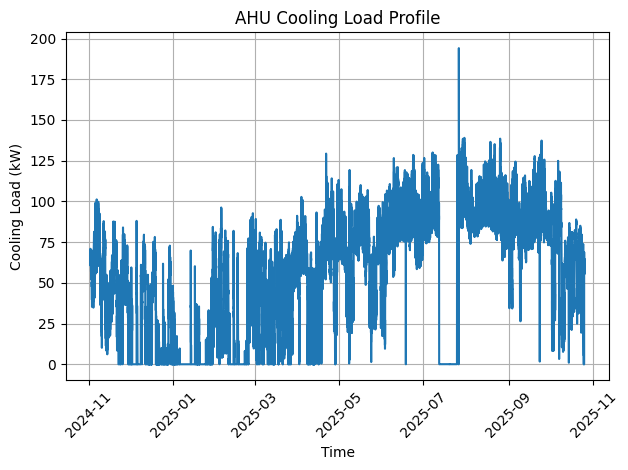

In [ ]:
#visualization
plt.figure()
plt.plot(merged_df["timestamp"], merged_df["cooling_load_kw_thermal"])

plt.xlabel("Time")
plt.ylabel("Cooling Load (kW)")
plt.title("AHU Cooling Load Profile")

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

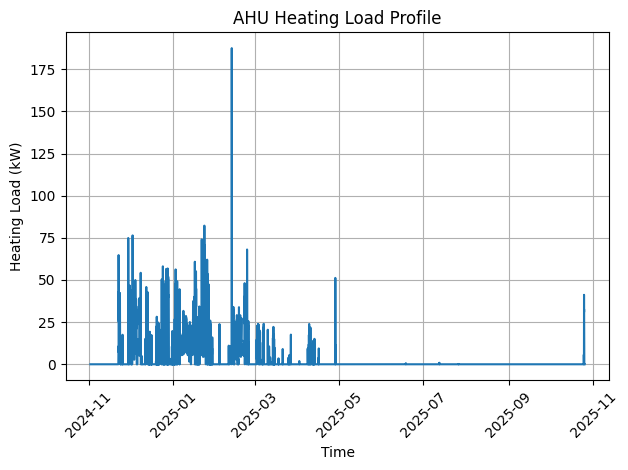

In [ ]:
plt.figure()
plt.plot(merged_df["timestamp"], merged_df["heating_load_kw_thermal"])

plt.xlabel("Time")
plt.ylabel("Heating Load (kW)")
plt.title("AHU Heating Load Profile")

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Total Energy Demand Calculation
merged_df["cooling_energy_kwh_thermal"] = merged_df["cooling_load_kw_thermal"] * 0.25
total_energy = merged_df["cooling_energy_kwh_thermal"].sum()
print("Total Cooling Energy (kWh thermal):", total_energy)

Total Cooling Energy (kWh thermal): 1887081.8442644246


In [ ]:
#Daily Energy Demand Calculation
merged_df["date"] = merged_df["timestamp"].dt.date
daily_energy = merged_df.groupby("date")["cooling_energy_kwh_thermal"].sum()
daily_energy

,cooling_energy_kwh_thermal
date,
2024-11-01,6.653482e+01
2024-11-02,1.477319e+03
2024-11-03,1.429144e+06
2024-11-04,1.340183e+03
2024-11-05,1.565742e+03
...,...
2025-10-21,1.355484e+03
2025-10-22,1.508586e+03
2025-10-23,1.260245e+03


## (3) Physics-based equation model: **Fan Energy** (Estimated)
Fan power is estimated using fan affinity laws:
\\[P \propto (\frac{speed}{100})^3\\]

where, P is fan power and speed is fan speed(%).

In [ ]:
# Estimate fan power using the fan’s rated horsepower and airflow (speed ratio)
design_cfm = merged_df["SA_CFM"].max()
design_power_kw = 7.36 ### please add your fan power input

merged_df["fan_power_kw_est"] = design_power_kw * (merged_df["SA_CFM"] / design_cfm) ** 3
merged_df["fan_energy_kwh"] = merged_df["fan_power_kw_est"] * 0.25

In [ ]:
total_fan_energy = merged_df["fan_energy_kwh"].sum()
print("Total Fan Energy (kWh):", total_fan_energy)

Total Fan Energy (kWh): 64371.78917983083


In [ ]:
fan_speed_cols = [
    "SF1_speed",
    "SF2_speed",
    "SF3_speed",
    "SF4_speed",
    "SF5_speed",
    "SF6_speed",
]

rated_bhp = 7.36
rated_kw_shaft = rated_bhp * 0.7457
motor_eff = 0.90
rated_kw_elec = rated_kw_shaft / motor_eff

print("Rated shaft power per fan (kW):", rated_kw_shaft)
print("Rated electric power per fan (kW):", rated_kw_elec)

for col in fan_speed_cols:
    power_col = col + "_power_kw_est"
    merged_df[power_col] = rated_kw_elec * (merged_df[col] / 100.0) ** 3

Rated shaft power per fan (kW): 5.488352000000001
Rated electric power per fan (kW): 6.09816888888889


In [ ]:
fan_power_cols = [col + "_power_kw_est" for col in fan_speed_cols]
merged_df["total_fan_power_kw_est"] = merged_df[fan_power_cols].sum(axis=1)
merged_df["total_fan_energy_kwh_est"] = merged_df["total_fan_power_kw_est"] * 0.25

merged_df[["timestamp"] + fan_speed_cols + ["total_fan_power_kw_est", "total_fan_energy_kwh_est"]].head()

,timestamp,SF1_speed,SF2_speed,SF3_speed,SF4_speed,SF5_speed,SF6_speed,total_fan_power_kw_est,total_fan_energy_kwh_est
0,2024-11-01 23:00:00,50.996346,50.996346,50.996346,50.996346,50.996346,50.996346,4.852526,1.213131
1,2024-11-01 23:15:00,49.974602,49.974602,49.974602,49.974602,49.974602,49.974602,4.566660,1.141665
2,2024-11-01 23:30:00,47.374275,47.374275,47.374275,47.374275,47.374275,47.374275,3.890258,0.972565
3,2024-11-01 23:45:00,52.612144,52.612144,52.612144,52.612144,52.612144,52.612144,5.328546,1.332136
4,2024-11-02 00:00:00,48.546005,48.546005,48.546005,48.546005,48.546005,48.546005,4.186115,1.046529


In [ ]:
print("Total Estimated Fan Energy (kWh):", merged_df["total_fan_energy_kwh_est"].sum())

Total Estimated Fan Energy (kWh): 195307.11485901452


In [ ]:
merged_df["date"] = merged_df["timestamp"].dt.date
daily_fan_energy = merged_df.groupby("date")["total_fan_energy_kwh_est"].sum()
daily_fan_energy

,total_fan_energy_kwh_est
date,
2024-11-01,4.659498
2024-11-02,106.758018
2024-11-03,138079.953720
2024-11-04,121.744798
2024-11-05,132.923395
...,...
2025-10-21,164.128036
2025-10-22,166.320239
2025-10-23,170.187535


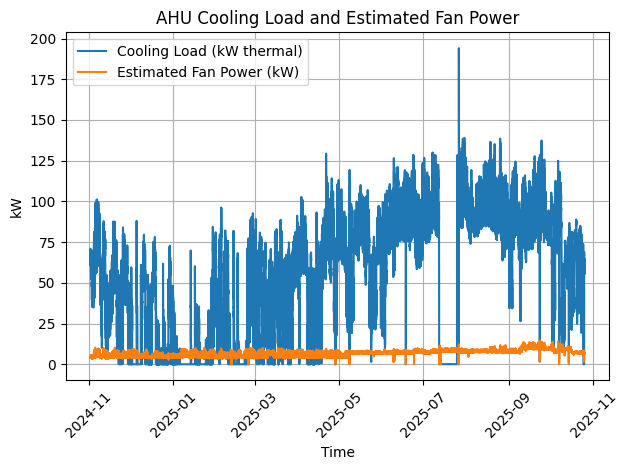

In [ ]:
plt.figure()
plt.plot(merged_df["timestamp"], merged_df["cooling_load_kw_thermal"], label="Cooling Load (kW thermal)")
plt.plot(merged_df["timestamp"], merged_df["total_fan_power_kw_est"], label="Estimated Fan Power (kW)")
plt.xlabel("Time")
plt.ylabel("kW")
plt.title("AHU Cooling Load and Estimated Fan Power")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# OA fraction >> the percentage of outdoor air mixed into the supply air
merged_df["OA_fraction"] = (merged_df["OA_CFM"] / merged_df["SA_CFM"]).replace([np.inf, -np.inf], np.nan)
merged_df["OA_fraction"] = merged_df["OA_fraction"].clip(lower=0, upper=1)

merged_df["deltaT_MA_SA"] = merged_df["MA_T"] - merged_df["SA_T"]
merged_df["deltaT_RA_OA"] = merged_df["RA_T"] - merged_df["OA_T"]

merged_df["fan_to_cooling_ratio"] = (
    merged_df["total_fan_power_kw_est"] / merged_df["cooling_load_kw_thermal"].replace(0, np.nan)
)

# Cooling mode helper
merged_df["is_cooling"] = merged_df["cooling_load_kw_thermal"] > 0


# **Layer 2.** Rule Configuration
Although HVAC systems operate based on physical principles, there are generally expected operating conditions that should be maintained. These conditions vary by building and depend on the characteristics of the equipment composing the cooling system, which requires significant engineering expertise.

However, ASHRAE provides standards and guidelines for energy-efficient operation of AHU systems. By applying these guidelines, it is possible to preliminarily assess whether the system is operating properly before conducting detailed analysis.

In [ ]:
RULE_CONFIG = {
    "economizer_temp_margin_f": 2.0,      # Economizer is favorable if OA is at least this much lower than RA
    "economizer_min_oa_frac": 0.30,       # If favorable, OA fraction below this level is considered too low
    "minimum_oa_frac": 0.10,              # Assumed minimum outdoor air requirement
    "excess_oa_tolerance": 0.15,          # OA fraction is too high above minimum under unfavorable conditions
    "low_load_kw": 20.0,                  # Threshold for low load condition
    "low_sat_f": 55.0,                    # Threshold to check if supply air temperature is too low
    "high_fan_power_kw": 20.0,            # Threshold to check if fan power is excessive
}

The rule engine function is constructed to include the following decision logic:

(1) Determine whether the economizer is favorable: if outdoor air is sufficiently cooler than return air, using the economizer is beneficial.

(2) Identify a missed economizer opportunity: if the system is in cooling mode and outdoor air conditions are favorable, but the actual outdoor air fraction is low, it is considered a missed economizer opportunity.

(3) Identify excess outdoor air: if outdoor air conditions are unfavorable but too much outdoor air is introduced, the cooling load may increase, indicating inefficient operation.

(4) Identify low SAT under low load: if the load is low but the SAT is too low, the system may be using unnecessary energy.

(5) Identify excessive fan energy: if the fan power is too high under low-load conditions, the system may be wasting energy on the air-side operation.


In [ ]:
# Takes a single row at a given timestamp, evaluates it, and returns any identified issues
def evaluate_ahu_energy_rules(row, cfg=RULE_CONFIG):
    violations = []
    checks = {}

    # Basic variables
    is_cooling = bool(row["is_cooling"])
    oa_t = row["OA_T"]
    ra_t = row["RA_T"]
    sa_t = row["SA_T"]
    oa_frac = row["OA_fraction"]
    cooling_kw = row["cooling_load_kw_thermal"]
    fan_kw = row["total_fan_power_kw_est"]

    # 1) Economizer favorable condition
    economizer_favorable = (
        pd.notna(oa_t) and pd.notna(ra_t) and
        (oa_t + cfg["economizer_temp_margin_f"] < ra_t)
    )
    checks["economizer_favorable"] = economizer_favorable

    # 2) Missed economizer opportunity
    missed_economizer = (
        is_cooling and economizer_favorable and
        pd.notna(oa_frac) and
        oa_frac < cfg["economizer_min_oa_frac"]
    )
    checks["missed_economizer"] = missed_economizer
    if missed_economizer:
        violations.append("Missed economizer opportunity")

    # 3) Excess outdoor air when OA is unfavorable
    oa_unfavorable = (
        pd.notna(oa_t) and pd.notna(ra_t) and
        (oa_t > ra_t + cfg["economizer_temp_margin_f"])
    )
    checks["oa_unfavorable"] = oa_unfavorable

    excess_oa = (
        is_cooling and oa_unfavorable and
        pd.notna(oa_frac) and
        oa_frac > (cfg["minimum_oa_frac"] + cfg["excess_oa_tolerance"])
    )
    checks["excess_outdoor_air"] = excess_oa
    if excess_oa:
        violations.append("Excess outdoor air intake during unfavorable outdoor conditions")

    # 4) Possible overcooling / low SAT at low load
    low_load = pd.notna(cooling_kw) and cooling_kw < cfg["low_load_kw"]
    checks["low_load"] = low_load

    low_sat_at_low_load = (
        is_cooling and low_load and
        pd.notna(sa_t) and
        sa_t < cfg["low_sat_f"]
    )
    checks["low_sat_at_low_load"] = low_sat_at_low_load
    if low_sat_at_low_load:
        violations.append("Supply air temperature may be lower than necessary under low load")

    # 5) Fan energy too high relative to demand
    high_fan_at_low_load = (
        is_cooling and low_load and
        pd.notna(fan_kw) and
        fan_kw > cfg["high_fan_power_kw"]
    )
    checks["high_fan_at_low_load"] = high_fan_at_low_load
    if high_fan_at_low_load:
        violations.append("Fan power appears high relative to cooling demand")

    # Overall assessment
    if len(violations) == 0:
        efficiency_status = "efficient"
    elif len(violations) == 1:
        efficiency_status = "needs review"
    else:
        efficiency_status = "inefficient"

    return {
        "efficiency_status": efficiency_status,
        "violations": violations,
        "violation_count": len(violations),
        "checks": checks,
    }


In [ ]:
# Attach the rule results to the DataFrame
rule_results = merged_df.apply(evaluate_ahu_energy_rules, axis=1)

merged_df["efficiency_status"] = rule_results.apply(lambda x: x["efficiency_status"])
merged_df["rule_violations"] = rule_results.apply(lambda x: "; ".join(x["violations"]) if x["violations"] else "None")
merged_df["violation_count"] = rule_results.apply(lambda x: x["violation_count"])

merged_df[[
    "timestamp", "mode", "cooling_load_kw_thermal", "total_fan_power_kw_est",
    "OA_fraction", "efficiency_status", "violation_count", "rule_violations"
]].head(10)

,timestamp,mode,cooling_load_kw_thermal,total_fan_power_kw_est,OA_fraction,efficiency_status,violation_count,rule_violations
0,2024-11-01 23:00:00,cooling,68.518705,4.852526,0.367636,efficient,0,None
1,2024-11-01 23:15:00,cooling,64.914165,4.566660,0.392402,efficient,0,None
2,2024-11-01 23:30:00,cooling,61.793008,3.890258,0.287620,needs review,1,Missed economizer opportunity
3,2024-11-01 23:45:00,cooling,70.913392,5.328546,0.361485,efficient,0,None
4,2024-11-02 00:00:00,cooling,63.086475,4.186115,0.386276,efficient,0,None
5,2024-11-02 00:15:00,cooling,63.383080,4.150113,0.332260,efficient,0,None
6,2024-11-02 00:30:00,cooling,65.503042,4.773487,0.331496,efficient,0,None
7,2024-11-02 00:45:00,cooling,68.673269,4.907114,0.341868,efficient,0,None
8,2024-11-02 01:00:00,cooling,62.457162,3.997441,0.322365,efficient,0,None
9,2024-11-02 01:15:00,cooling,67.203855,4.799827,0.357643,efficient,0,None


# Layer 3. Prompt Builder
Organize the calculated results into a structure that can be understood by an LLM. Python code computes physics-based operational indicators from BAS data. An OpenAI API-based LLM then interprets the operational status, generates reports, and answers questions based on these results.

In [ ]:
# Create OpenAI client
os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")
client = OpenAI()

Enter your OpenAI API key: ··········


In [ ]:
api_key = os.getenv("OPENAI_API_KEY") #connect with LLM (I used OpenAI API in this project)

**Generate a summary for the LLM**

The original row contains many unnecessary columns and mixed pandas data types, so only the required values are selected, rounded, and reformatted into a JSON-friendly structure.

In [ ]:
def build_interval_summary(row):
    return {
        "timestamp": str(row["timestamp"]),
        "mode": row["mode"],
        "mixed_air_temp_f": round(float(row["MA_T"]), 2),
        "supply_air_temp_f": round(float(row["SA_T"]), 2),
        "return_air_temp_f": round(float(row["RA_T"]), 2) if pd.notna(row["RA_T"]) else None,
        "outdoor_air_temp_f": round(float(row["OA_T"]), 2) if pd.notna(row["OA_T"]) else None,
        "supply_airflow_cfm": round(float(row["SA_CFM"]), 2),
        "outdoor_airflow_cfm": round(float(row["OA_CFM"]), 2) if pd.notna(row["OA_CFM"]) else None,
        "outdoor_air_fraction": round(float(row["OA_fraction"]), 3) if pd.notna(row["OA_fraction"]) else None,
        "cooling_load_kw_thermal": round(float(row["cooling_load_kw_thermal"]), 2),
        "fan_power_kw_est": round(float(row["total_fan_power_kw_est"]), 2),
        "efficiency_status": row["efficiency_status"],
        "violation_count": int(row["violation_count"]),
        "rule_violations": row["rule_violations"].split("; ") if row["rule_violations"] != "None" else []
    }

## (1) Baseline Prompt

Construct a baseline prompt to generate a JSON-format report using the given data.
This model is intended to evaluate how well a general prompt-only LLM performs, so it uses relatively simple instructions.

In [ ]:
def build_json_prompt_baseline(summary):
    return f"""
You are an HVAC diagnostic assistant.

Use the provided physics-based indicators and rule-evaluation results.
Return your answer as a valid JSON object only.
Do not include markdown fences.
Do not include any text before or after the JSON.

Input data:
{json.dumps(summary, indent=2)}

Return JSON with exactly this structure:
{{
  "operational_summary": "...",
  "efficiency_assessment": "...",
  "key_issues": "...",
  "engineering_interpretation": "...",
  "recommendation": "..."
}}
"""

## (2) Improved Prompt
Even with the same model, the quality of results can vary depending on how the question is asked. This section evaluates whether prompt design can improve the quality of engineering judgment.

In cooling systems, physical behavior and operational appropriateness are governed by rules and criteria. Therefore, this task focuses on how well the model can interpret the given data and explain the system’s condition in natural language, which is why a prompt engineering strategy is adopted.

Compared to the baseline, this prompt includes more detailed instructions, such as: write based on evidence, provide recommendations aligned with severity, and avoid excessive assumptions.

In [ ]:
def build_json_prompt_improved(summary):
    return f"""
You are a senior HVAC diagnostic assistant with expertise in AHU operation, energy efficiency, and BAS-based engineering interpretation.

Your task is to produce a structured diagnostic report using:
1. physics-based indicators
2. rule-evaluation results
3. careful engineering judgment grounded in the given evidence

You may provide additional engineering interpretation beyond the rule flags, but every important claim must be supported by the provided input.
Do not mention sensors or faults that are not supported by the given data.
Do not invent exact values for humidity, enthalpy, COP, or equipment faults unless explicitly stated.
Recommendations must match the severity of the case:
- efficient -> maintain / monitor
- needs review -> focused recommendation
- inefficient -> corrective recommendation

Each field must be concise and specific.
Use at most 2-3 sentences per field.

Return your answer as a valid JSON object only.
Do not include markdown fences.
Do not include any text before or after the JSON.

Input data:
{json.dumps(summary, indent=2)}

Return JSON with exactly this structure:
{{
  "operational_summary": "...",
  "efficiency_assessment": "...",
  "key_issues": "...",
  "engineering_interpretation": "...",
  "recommendation": "...",
  "evidence_used": ["...", "...", "..."]
}}
"""

## (3) LLM Call

Call the API, receive the response, parse it as a JSON file, and return the result. To compare the baseline and improved prompts, both are executed in the same way, leaving only the prompt different.

Before that, a recovery function is written in case the LLM does not perfectly follow the JSON format. If parsing succeeds, it returns a valid JSON object; if parsing fails, the code stops.

In [ ]:
def safe_json_load(text):
    try:
        return json.loads(text)
    except:
        return {
            "operational_summary": text[:300],
            "efficiency_assessment": "",
            "key_issues": "",
            "engineering_interpretation": "",
            "recommendation": "",
            "evidence_used": []
        }


def generate_llm_json_report(summary, client, mode="baseline", model="gpt-5"):
    if mode == "baseline":
        prompt = build_json_prompt_baseline(summary)
    elif mode == "improved":
        prompt = build_json_prompt_improved(summary)
    else:
        raise ValueError("mode must be 'baseline' or 'improved'")

    response = client.responses.create(
        model=model,
        input=prompt
    )

    text = response.output_text.strip()
    return safe_json_load(text)

In [ ]:
def generate_llm_json_report(summary, client, model="gpt-5", mode="baseline"):

    if mode == "baseline":
        prompt = build_json_prompt_baseline(summary)
    else:
        prompt = build_json_prompt_improved(summary)

    response = client.responses.create(
        model=model,
        input=prompt
    )

    text = response.output_text.strip()

    return safe_json_load(text)

## (4) Generate Final Results
To create a complete diagnostic result for one timestamp, the process takes a single row, generates a summary using `build_interval_summary(row)`, creates a report using `generate_llm_json_report()`, and combines the physics-based values, rule-based results, and LLM report into one object.

In [ ]:
def build_final_record(row, client, mode="baseline"):
    summary = build_interval_summary(row)
    llm_report = generate_llm_json_report(summary, client, mode=mode)

    final_record = {
        "timestamp": summary["timestamp"],
        "mode": summary["mode"],
        "physics_features": {
            "mixed_air_temp_f": summary["mixed_air_temp_f"],
            "supply_air_temp_f": summary["supply_air_temp_f"],
            "return_air_temp_f": summary["return_air_temp_f"],
            "outdoor_air_temp_f": summary["outdoor_air_temp_f"],
            "supply_airflow_cfm": summary["supply_airflow_cfm"],
            "outdoor_airflow_cfm": summary["outdoor_airflow_cfm"],
            "outdoor_air_fraction": summary["outdoor_air_fraction"],
            "cooling_load_kw_thermal": summary["cooling_load_kw_thermal"],
            "fan_power_kw_est": summary["fan_power_kw_est"]
        },
        "rule_evaluation": {
            "efficiency_status": summary["efficiency_status"],
            "violation_count": summary["violation_count"],
            "violations": summary["rule_violations"]
        },
        "llm_mode": mode,
        "llm_report": llm_report
    }

    return final_record

In [ ]:
# Generate baseline results loop >> select the first 3 timestamps from the DataFrame and generate reports using the baseline prompt
baseline_results = []

for i in range(3):
    print(f"[Baseline] Processing row {i+1}/3...")
    row = merged_df.iloc[i]
    record = build_final_record(row, client, mode="baseline")
    baseline_results.append(record)

print("Baseline done.")

[Baseline] Processing row 1/3...
[Baseline] Processing row 2/3...
[Baseline] Processing row 3/3...
Baseline done.


In [ ]:
# Generate improved results loop
improved_results = []

for i in range(3):
    print(f"[Improved] Processing row {i+1}/3...")
    row = merged_df.iloc[i]
    record = build_final_record(row, client, mode="improved")
    improved_results.append(record)

print("Improved done.")

[Improved] Processing row 1/3...
[Improved] Processing row 2/3...
[Improved] Processing row 3/3...
Improved done.


In [ ]:
# Save as JSON
with open("ahu_diagnostic_reports_baseline.json", "w", encoding="utf-8") as f:
    json.dump(baseline_results, f, indent=2, ensure_ascii=False)

with open("ahu_diagnostic_reports_improved.json", "w", encoding="utf-8") as f:
    json.dump(improved_results, f, indent=2, ensure_ascii=False)

print("Saved baseline and improved reports.")

Saved baseline and improved reports.


In [ ]:
for i in range(len(baseline_results)):
    print("=" * 80)
    print(f"Sample {i+1}")
    print("- Timestamp:", baseline_results[i]["timestamp"])
    print("- Rule status:", baseline_results[i]["rule_evaluation"]["efficiency_status"])
    print()

    print("[Baseline recommendation]")
    print(baseline_results[i]["llm_report"].get("recommendation", ""))
    print()

    print("[Improved recommendation]")
    print(improved_results[i]["llm_report"].get("recommendation", ""))
    print()

Sample 1
- Timestamp: 2024-11-01 23:00:00
- Rule status: efficient

[Baseline recommendation]
Enable/increase economizer to the maximum that maintains SAT and humidity (target MAT ~1–2°F above SAT) to trim mechanical cooling; consider a nighttime SAT reset upward (e.g., 56–58°F) if zone conditions allow; verify OA/return damper modulation and sensor calibration; continue current fan setup (power per cfm is efficient).

[Improved recommendation]
Maintain current operation and continue monitoring. Verify economizer sequencing allows OA fraction to increase when OAT < RAT and conditions permit, to shave compressor load without compromising ventilation or humidity control.

Sample 2
- Timestamp: 2024-11-01 23:15:00
- Rule status: efficient

[Baseline recommendation]
Maintain current operation. Keep economizer enabled while outdoor air remains cooler than return air. Verify outdoor air setpoint aligns with occupancy schedule and humidity control targets; reduce to minimum OA during unoccupi

## (5) Evaluation
Reload the saved JSON file and evaluate the baseline and improved results.

This separates the generation stage from the evaluation stage so that the previously generated results can be reused.

In [ ]:
with open("/content/ahu_diagnostic_reports_baseline.json", "r", encoding="utf-8") as f:
    baseline_results = json.load(f)

with open("/content/ahu_diagnostic_reports_improved.json", "r", encoding="utf-8") as f:
    improved_results = json.load(f)

print("Baseline samples:", len(baseline_results))
print("Improved samples:", len(improved_results))

Baseline samples: 3
Improved samples: 3


In [ ]:
# Combine multiple text fields in the LLM report into one evaluation text.
def flatten_report_text(record):
    """
    llm_report 안의 주요 텍스트를 하나로 합침
    """
    report = record.get("llm_report", {})
    fields = [
        report.get("operational_summary", ""),
        report.get("efficiency_assessment", ""),
        report.get("key_issues", ""),
        report.get("engineering_interpretation", ""),
        report.get("recommendation", "")
    ]
    return " ".join([str(x) for x in fields if x]).lower()


def detect_report_label(text):
    """
    LLM report에서 overall judgment를 간단히 추정
    """
    text = text.lower()

    if "inefficient" in text:
        return "inefficient"
    if "needs review" in text or "review" in text:
        return "needs review"
    if "efficient" in text:
        return "efficient"

    return "unknown"


In [ ]:
# Measure consistency between the LLM report and the rule-based results.
def rule_consistency_score(record):
    """
    Evaluate whether the ground truth from the rule evaluation aligns with the tone and judgment of the report.
    1 = consistent, 0 = inconsistent
    """
    true_status = record.get("rule_evaluation", {}).get("efficiency_status", "").lower()
    text = flatten_report_text(record)
    predicted_status = detect_report_label(text)

    # If a judgment is not explicitly stated in the report, mark it as "unknown"
    if predicted_status == "unknown":
        return 0

    # exact match
    if predicted_status == true_status:
        return 1

    # Option to allow slight flexibility
    # Example: treat "inefficient" and "needs review" as mismatched (not equivalent)
    return 0

In [ ]:
# Check for overreach: verify whether the LLM introduces concepts not present in the input
def hallucination_flags(record):
    """
    Simply check whether the report excessively mentions concepts not included in the input
    Based on suspicious keywords defined for the current project
    """
    text = flatten_report_text(record)

    suspicious_terms = {
        "humidity": [r"\bhumidity\b", r"\bhumid\b"],
        "enthalpy": [r"\benthalpy\b"],
        "cop": [r"\bcop\b"],
        "dewpoint": [r"\bdew ?point\b"],
        "damper_fault": [r"\bdamper fault\b", r"\bstuck damper\b", r"\bactuator fault\b"],
        "sensor_fault": [r"\bsensor fault\b", r"\bfailed sensor\b"],
        "compressor_power_estimate": [r"\bcompressor\b", r"\bcompressor power\b"],
    }

    found = []

    for label, patterns in suspicious_terms.items():
        for p in patterns:
            if re.search(p, text):
                found.append(label)
                break

    return found

# Count the number of flags found by the function
def hallucination_score(record):
    """
    Number of hallucination / overreach cases
    Lower is better
    """
    return len(hallucination_flags(record))


In [ ]:
#Score how practical the report is (heuristic)
def usefulness_score(record):
    """
    Simple heuristic usefulness score (1–5)
    This is not a perfect evaluation, but is used for temporary automatic evaluation
    """
    report = record.get("llm_report", {})
    rec = str(report.get("recommendation", "")).lower()
    issues = str(report.get("key_issues", "")).lower()
    evidence = report.get("evidence_used", [])

    score = 1

    # +1 if a recommendation is provided
    if len(rec.strip()) > 20:
        score += 1

    # +1 if specific action verbs are used
    action_words = ["verify", "check", "adjust", "maintain", "monitor", "increase", "reduce", "trend", "enable", "calibrate", "test"]
    if any(w in rec for w in action_words):
        score += 1

    # +1 if key issues are described concretely
    if len(issues.strip()) > 20:
        score += 1

    # +1 if evidence_used is included
    if isinstance(evidence, list) and len(evidence) >= 2:
        score += 1

    return min(score, 5)

In [ ]:
# Generate an evaluation table from the result list >> convert natural language reports into a numerical evaluation table
def evaluate_records(records, model_name):
    rows = []

    for i, record in enumerate(records):
        halluc_flags = hallucination_flags(record)

        row = {
            "sample_id": i + 1,
            "model": model_name,
            "timestamp": record.get("timestamp", ""),
            "true_status": record.get("rule_evaluation", {}).get("efficiency_status", ""),
            "violation_count": record.get("rule_evaluation", {}).get("violation_count", None),
            "rule_consistency": rule_consistency_score(record),
            "hallucination_score": hallucination_score(record),
            "hallucination_flags": ", ".join(halluc_flags) if halluc_flags else "",
            "usefulness_score": usefulness_score(record),
            "recommendation": record.get("llm_report", {}).get("recommendation", "")
        }
        rows.append(row)

    return pd.DataFrame(rows)

In [ ]:
#baseline evaluation tables
baseline_eval_df = evaluate_records(baseline_results, "baseline")
improved_eval_df = evaluate_records(improved_results, "improved")

baseline_eval_df

,sample_id,model,timestamp,true_status,violation_count,rule_consistency,hallucination_score,hallucination_flags,usefulness_score,recommendation
0,1,baseline,2024-11-01 23:00:00,efficient,0,1,1,humidity,4,Enable/increase economizer to the maximum that...
1,2,baseline,2024-11-01 23:15:00,efficient,0,1,1,humidity,4,Maintain current operation. Keep economizer en...
2,3,baseline,2024-11-01 23:30:00,needs review,1,1,5,"humidity, enthalpy, cop, dewpoint, compressor_...",4,Enable and tune economizer for dry-bulb/enthal...


In [ ]:
#improved evaluation tables
improved_eval_df

,sample_id,model,timestamp,true_status,violation_count,rule_consistency,hallucination_score,hallucination_flags,usefulness_score,recommendation
0,1,improved,2024-11-01 23:00:00,efficient,0,1,2,"humidity, compressor_power_estimate",5,Maintain current operation and continue monito...
1,2,improved,2024-11-01 23:15:00,efficient,0,1,1,humidity,5,Maintain current operation and monitor. If eco...
2,3,improved,2024-11-01 23:30:00,needs review,1,1,1,humidity,5,Review economizer enable/high-limit logic and ...


In [ ]:
all_eval_df = pd.concat([baseline_eval_df, improved_eval_df], ignore_index=True)
all_eval_df

,sample_id,model,timestamp,true_status,violation_count,rule_consistency,hallucination_score,hallucination_flags,usefulness_score,recommendation
0,1,baseline,2024-11-01 23:00:00,efficient,0,1,1,humidity,4,Enable/increase economizer to the maximum that...
1,2,baseline,2024-11-01 23:15:00,efficient,0,1,1,humidity,4,Maintain current operation. Keep economizer en...
2,3,baseline,2024-11-01 23:30:00,needs review,1,1,5,"humidity, enthalpy, cop, dewpoint, compressor_...",4,Enable and tune economizer for dry-bulb/enthal...
3,1,improved,2024-11-01 23:00:00,efficient,0,1,2,"humidity, compressor_power_estimate",5,Maintain current operation and continue monito...
4,2,improved,2024-11-01 23:15:00,efficient,0,1,1,humidity,5,Maintain current operation and monitor. If eco...
5,3,improved,2024-11-01 23:30:00,needs review,1,1,1,humidity,5,Review economizer enable/high-limit logic and ...


In [ ]:
#aggregate performance summary
summary_df = all_eval_df.groupby("model")[[
    "rule_consistency",
    "hallucination_score",
    "usefulness_score"
]].mean().reset_index()

summary_df

,model,rule_consistency,hallucination_score,usefulness_score
0,baseline,1.0,2.333333,4.0
1,improved,1.0,1.333333,5.0


In [ ]:
#side-by-side model comparison
comparison_df = baseline_eval_df.merge(
    improved_eval_df,
    on="sample_id",
    suffixes=("_baseline", "_improved")
)

comparison_df[[
    "sample_id",
    "true_status_baseline",
    "rule_consistency_baseline",
    "rule_consistency_improved",
    "hallucination_score_baseline",
    "hallucination_score_improved",
    "usefulness_score_baseline",
    "usefulness_score_improved"
]]

,sample_id,true_status_baseline,rule_consistency_baseline,rule_consistency_improved,hallucination_score_baseline,hallucination_score_improved,usefulness_score_baseline,usefulness_score_improved
0,1,efficient,1,1,1,2,4,5
1,2,efficient,1,1,1,1,4,5
2,3,needs review,1,1,5,1,4,5


In [ ]:
comparison_df["rule_consistency_gain"] = (
    comparison_df["rule_consistency_improved"] - comparison_df["rule_consistency_baseline"]
)

comparison_df["hallucination_reduction"] = (
    comparison_df["hallucination_score_baseline"] - comparison_df["hallucination_score_improved"]
)

comparison_df["usefulness_gain"] = (
    comparison_df["usefulness_score_improved"] - comparison_df["usefulness_score_baseline"]
)

comparison_df[[
    "sample_id",
    "rule_consistency_gain",
    "hallucination_reduction",
    "usefulness_gain"
]]

,sample_id,rule_consistency_gain,hallucination_reduction,usefulness_gain
0,1,0,-1,1
1,2,0,0,1
2,3,0,4,1


In [ ]:
# representative case analysis
for i in range(len(baseline_results)):
    print("=" * 100)
    print(f"Sample {i+1}")
    print("True status:", baseline_results[i]["rule_evaluation"]["efficiency_status"])
    print()

    print("[Baseline - recommendation]")
    print(baseline_results[i]["llm_report"].get("recommendation", ""))
    print("Hallucination flags:", hallucination_flags(baseline_results[i]))
    print()

    print("[Improved - recommendation]")
    print(improved_results[i]["llm_report"].get("recommendation", ""))
    print("Hallucination flags:", hallucination_flags(improved_results[i]))
    print()

Sample 1
True status: efficient

[Baseline - recommendation]
Enable/increase economizer to the maximum that maintains SAT and humidity (target MAT ~1–2°F above SAT) to trim mechanical cooling; consider a nighttime SAT reset upward (e.g., 56–58°F) if zone conditions allow; verify OA/return damper modulation and sensor calibration; continue current fan setup (power per cfm is efficient).
Hallucination flags: ['humidity']

[Improved - recommendation]
Maintain current operation and continue monitoring. Verify economizer sequencing allows OA fraction to increase when OAT < RAT and conditions permit, to shave compressor load without compromising ventilation or humidity control.
Hallucination flags: ['humidity', 'compressor_power_estimate']

Sample 2
True status: efficient

[Baseline - recommendation]
Maintain current operation. Keep economizer enabled while outdoor air remains cooler than return air. Verify outdoor air setpoint aligns with occupancy schedule and humidity control targets; red

In [ ]:
#saving evaluation results
baseline_eval_df.to_csv("/content/baseline_eval.csv", index=False)
improved_eval_df.to_csv("/content/improved_eval.csv", index=False)
summary_df.to_csv("/content/eval_summary.csv", index=False)
comparison_df.to_csv("/content/eval_comparison.csv", index=False)

print("Saved evaluation CSV files.")

Saved evaluation CSV files.
